In [30]:
from pathlib import Path
import scipy.io as scio
import pandas as pd
import numpy as np
import numpy.linalg as LA
import matplotlib.pyplot as plt
from copy import deepcopy

In [21]:
def hierarchichal_clustering(fc_mat, NB_ROI=400):
    '''Compute spectral clusters and return the number of clusters and their size at every level'''
    fc_mat[fc_mat<0]=0
    _, modes = LA.eigh(fc_mat)
    modes = np.fliplr(modes).T

    clus_num = [] #Number of clusters for each order
    clus_size = [] #Elements are arrays of cluster size for each order
    clusters = [] #Elements are arrays of positions for each clusters in the previous order
    clus_num.append(1) #First mode only has one module
    clus_size.append([NB_ROI]) #First mode has one module of size 360

    clusters.append((modes[1]<0).nonzero()) #Initialize clusters of 2nd mode
    clusters.append((modes[1]>=0).nonzero())
    clus_num.append(2) #The 2nd mode always has 2 clusters (1 pos and 1neg)

    for order in range(2,NB_ROI):
        x = (modes[order]>=0).nonzero() #Get indices for positive values
        y = (modes[order]<0).nonzero() #Get indices for negative values
        length = []
        new_clus = []
        for cluster in clusters: #Find clusters of mode N
            length.append(np.size(cluster)) #Find length of clusters at order-1
            if np.size(cluster)<=1:
                new_clus.append(cluster)
            else:
                if np.size(np.intersect1d(x,cluster)) >= 1 : new_clus.append(np.intersect1d(x,cluster))
                if np.size(np.intersect1d(y,cluster)) >= 1 : new_clus.append(np.intersect1d(y,cluster))
        clus_size.append(length)
        clusters = new_clus #Update new cluster
        clus_num.append(len(clusters))
    #Find length of clusters at order=NB_ROI
    length=[]
    for cluster in clusters:
        length.append(np.size(cluster))
    clus_size.append(length)
    return clus_size, clus_num

def segint_component(fc, clus_size, clus_num, NB_ROI=400):
    '''Given the spectral cluster, compute the integration and segregation components'''
    clus_num = np.divide(clus_num,400)
    fc = (fc + fc.T)/2
    fc[fc<0] = 0
    evals, modes = LA.eigh(fc)
    evals[evals<0] = 0
    evals = np.flip(np.square(evals))
    p=np.zeros(NB_ROI)
    hf=np.zeros(NB_ROI)    #Compute correction p
    for i in range(0,NB_ROI):
        c = 1/clus_num[i]
        p[i] = np.sum(abs(np.asarray(clus_size[i])-c)/NB_ROI)
    for i in range(0,NB_ROI):
        hf[i] = evals[i] * clus_num[i] * (1-p[i])
    hin = hf[0]/NB_ROI
    hse = np.sum(hf[1:])/NB_ROI
    return hin, hse


In [22]:
fc_file = r"C:\Users\busat\Desktop\PP\practical_project\data\FC_gamb.mat"
FC_data = {}
#nsp_data = {}
nsp_balance = {}

In [35]:
var_name = "FC_gamb"

mat_contents = scio.loadmat(fc_file)

var_keys = [k for k in mat_contents.keys() if not k.startswith("__")]
if not var_keys:
        raise ValueError(f"No variable found in {fc_file.name}") 

FC_matrix = mat_contents[var_keys[0]]  # should be 400 x 400 x subjects

FC_data[var_name] = FC_matrix
print(f"{var_name} loaded with shape {FC_matrix.shape}")

n_subjects = FC_data[var_name].shape[2]

clus_size_key = var_name + "_clus_size"
clus_num_key  = var_name + "_clus_num"

#nsp_data[clus_size_key] = []
#nsp_data[clus_num_key]  = []
nsp_balance[var_name] = []


FC_gamb loaded with shape (400, 400, 753)


TypeError: list indices must be integers or slices, not str

-0.9092986282916418


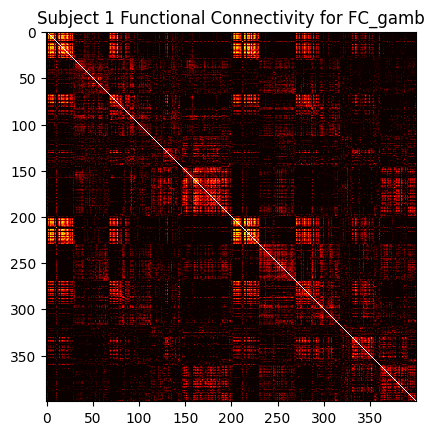

In [32]:
# plot functional connectivity
s=1
fc = deepcopy(FC_data[var_name][:,:,s])
clus_size, clus_num = hierarchichal_clustering(fc, NB_ROI=400)
hint,hseg = segint_component(fc, clus_size, clus_num, NB_ROI=400)
hbal = hint - hseg
plt.imshow(fc, cmap='hot', interpolation='nearest')
plt.title(f"Subject {s} Functional Connectivity for {var_name}")
print(hbal)

-0.1652243432822763


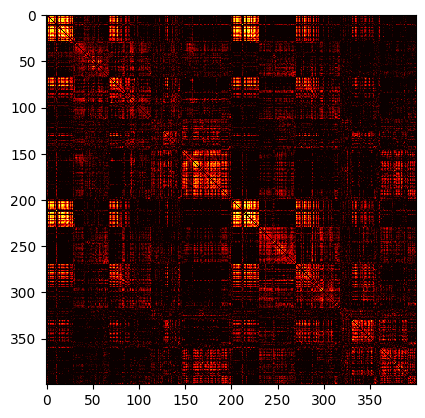

In [33]:
# Diagonale = 1
s=1
fc = deepcopy(FC_data[var_name][:,:,s])
np.fill_diagonal(fc,0)
clus_size, clus_num = hierarchichal_clustering(fc, NB_ROI=400)
hint,hseg = segint_component(fc, clus_size, clus_num, NB_ROI=400)
hbal = hint - hseg
nsp_balance[var_name].append(hbal)
plt.imshow(fc, cmap='hot', interpolation='nearest')
print(hbal)

Text(0.5, 1.0, 'NSp Balance Histogram for FC_gamb')

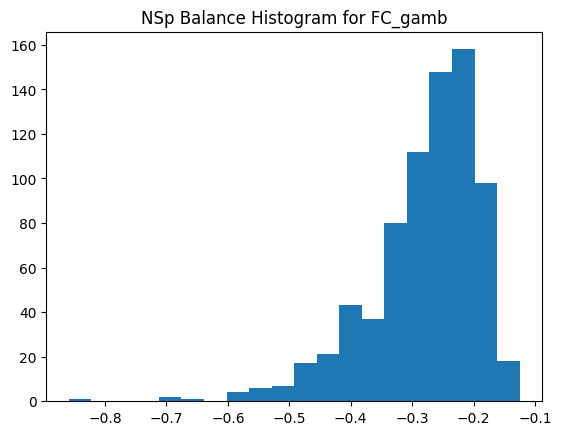

In [37]:
nsp_balance = []
for s in range(n_subjects):
    fc = deepcopy(FC_data[var_name][:,:,s])
    np.fill_diagonal(fc,0)
    clus_size, clus_num = hierarchichal_clustering(fc)
    hint,hseg = segint_component(fc, clus_size, clus_num)
    hbal = hint - hseg
    nsp_balance.append(hbal)

# plot histogram hbal
plt.hist(nsp_balance, bins=20)
plt.title(f"NSp Balance Histogram for {var_name}")